**ISCB-GMDS 2026 (Pre-conference Course)**
**Clinical Text Mining Under Real-World Constraints**
Vittorio Torri, Francesca Ieva

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vittot/ISCB-NLP-Course-2026/blob/main/notebooks/ex4_llm_prompting_t4.ipynb)

# EX 4 Information extraction with LLM prompting

**Goal.** Extract structured fields from clinical notes with zero-shot prompting of an
open-weight LLM, instead of a fine-tuned classifier -- the approach to reach for when
labels are scarce and, as here, privacy rules keep the data off proprietary cloud APIs.
This is a simplified, Colab-friendly replica of the system in *Polimi at CRF Filling
2026: Prompt-Based Information Extraction from Italian Clinical Notes* (Torri & Ieva),
built for the [CRF Filling Shared Task
2026](https://github.com/vittot/CRF-Filling-SharedTask-CL4Health26): it extracts 134
structured fields (symptoms, vital signs, history, diagnostic tests, treatments) from
Italian ED notes, reaching F1 = 67.5% on the dev set with a glossary of abbreviations,
3 prompts split by field type, and deterministic post-processing.

**What's different here, and why:**

- **English data.** The original work used the Italian notes; the paper explicitly
  flags "the use of English prompts on Italian data" and cross-lingual generalisation
  as future work. The shared task also released English-translated notes
  (`NLP-FBK/dyspnea-crf-development`, `en` split) with the *same* 134-item schema, so we
  use those directly instead.
- **A smaller, Colab-friendly model.** The paper's best model (Mistral-Small-3.2-24B)
  needed a full H100 -- too large for Colab. The setup cell offers two profiles:
  - `a100` (Colab Pro, GPU with 24 GB or more): **Llama-3.1-8B-Instruct** in bf16 (loaded from a
    public, non-gated mirror of the same weights, so no license or token is needed), which the
    paper *also* tested as its own zero-shot baseline (F1 = 52.84% on Italian), so our
    numbers are at least anchored to a result the original authors already reported.
  - `t4` (free Colab, T4 with 16 GB): **Qwen2.5-3B-Instruct** in fp16. It is much smaller,
    so expect lower scores and no direct paper reference to compare with; the *relative*
    gains between the stages below are what matters.
- **Only the main prompt variants.** The paper explored 20 configurations (Table 1);
  we replicate the five that tell the core story -- simple prompt -> add explicit
  rules -> add a glossary -> split into 3 prompts -> add post-processing -- skipping
  few-shot prompting, the LLM-based verifiers, synthetic-example generation, and
  ensembling (the paper itself found these added complexity without improving the
  final result).
- **A hand-written glossary** instead of mining one from the 2,667-note unlabelled
  corpus. The original glossary-construction pipeline (regex acronym extraction + an
  LLM confidence-scoring pass, Section 2.2.3 of the paper) is a project in its own
  right; here we reuse a glossary of the same kind directly.
- **A small, illustrative post-processing rule set** (3 rules) instead of the full
  library in the original repository, translated in spirit to English rather than
  translating dozens of Italian regexes verbatim.

**Requirements**: a Google Colab runtime with a GPU. Free Colab (T4) works with the `t4`
profile; the `a100` profile needs a GPU with at least 24 GB (Colab Pro: A100 or L4). The profile is
picked automatically from the GPU memory, and can be forced with `GPU_PROFILE` in the setup cell.
Neither profile needs a Hugging Face token or license acceptance.

## 1. Setup

In [1]:
!pip install -q "vllm>=0.10" datasets huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72

In [2]:
!pip uninstall -y -q torchaudio

In [1]:
import re
import json
import time
from collections import defaultdict

import pandas as pd
import torch
from datasets import load_dataset

# --- Model selection ---------------------------------------------------------
#   "a100": Llama-3.1-8B-Instruct, bf16 (~16 GB). Colab Pro (A100/L4, >= 24 GB).
#           The paper's own baseline. Loaded from a public, non-gated mirror of the
#           same weights (NousResearch), so no license acceptance or HF_TOKEN is needed.
#   "t4":   Qwen2.5-3B-Instruct, fp16 (~6 GB). Free Colab (T4, 16 GB).
#   None:   choose automatically from the GPU memory.
GPU_PROFILE = None

MODEL_PROFILES = {
    "a100": dict(model="NousResearch/Meta-Llama-3.1-8B-Instruct", dtype="bfloat16"),
    "t4":   dict(model="Qwen/Qwen2.5-3B-Instruct",                dtype="float16"),
}

assert torch.cuda.is_available(), "No GPU found: use Runtime > Change runtime type > GPU."
gpu_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
if GPU_PROFILE is None:
    GPU_PROFILE = "a100" if gpu_gb >= 22 else "t4"
MODEL_CFG = MODEL_PROFILES[GPU_PROFILE]
MODEL_NAME, MODEL_DTYPE = MODEL_CFG["model"], MODEL_CFG["dtype"]
print(f"GPU: {torch.cuda.get_device_name(0)} ({gpu_gb:.0f} GB) -> profile '{GPU_PROFILE}': {MODEL_NAME} ({MODEL_DTYPE})")

pd.set_option("display.max_colwidth", 100)


GPU: Tesla T4 (16 GB) -> profile 't4': Qwen/Qwen2.5-3B-Instruct (float16)


## 2. Load data and schema

`dyspnea-crf-development` (`en` split) has the 80 dev notes with 134-item annotations
each; `dyspnea-valid-options` has the schema (allowed values per item). Both come
directly from the shared task's Hugging Face org.

In [2]:
notes_ds = load_dataset("NLP-FBK/dyspnea-crf-development")["en"]
options_ds = load_dataset("NLP-FBK/dyspnea-valid-options")["train"]

item_to_opts = {row["item"]: row["options"] for row in options_ds}
gold = {
    row["document_id"]: {a["item"]: a["ground_truth"] for a in row["annotations"]}
    for row in notes_ds
}
notes = {row["document_id"]: row["clinical_note"] for row in notes_ds}

print(f"{len(notes)} English dev notes, {len(item_to_opts)} CRF items per note.")
print("Example note:\n", next(iter(notes.values()))[:300])

README.md:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

data/it-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 56.5kB            

data/it-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/en-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 59.6kB            

data/en-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

README.md:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 4.42kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/134 [00:00<?, ? examples/s]

80 English dev notes, 134 CRF items per note.
Example note:
 77-year-old patient. 
Past Medical History: cognitive impairment; lives with RELATIVE and RELATIVE; hearing loss. arterial hypertension, previous Guillain-Barré syndrome in 2007
spinal stabilization surgery in 1993, previous hysterectomy for fibroids, hiatal hernia, cholecystectomy
SAD, Last geriatr


In [3]:
# Same grouping rule as the original pipeline: an item is "measured" if the schema
# says so, "binary" if its only options are a subset of {y, n, unknown}, else
# "categorical" (multi-class, e.g. body temperature: hypothermic/normothermic/...).
binary_items, categorical_items, measured_items = [], [], []
for item, opts in item_to_opts.items():
    lower = {o.lower() for o in opts}
    if "measured" in lower:
        measured_items.append(item)
    elif lower.issubset({"y", "n", "unknown"}) and "unknown" in lower:
        binary_items.append(item)
    else:
        categorical_items.append(item)

print(f"binary={len(binary_items)}  categorical={len(categorical_items)}  measured={len(measured_items)}  (total={len(item_to_opts)})")

binary=89  categorical=21  measured=24  (total=134)


## 3. Prompt building blocks

A JSON schema (for vLLM's structured/constrained decoding -- the model is *guaranteed*
to emit valid values, not just asked nicely to) and a human-readable rules block are
built from the same schema for any subset of items, so every stage below reuses this
one function.

In [4]:
def build_schema_and_rules(items):
    schema = {"type": "object", "properties": {}, "required": []}
    rules = []
    for item in items:
        opts = item_to_opts[item]
        if any(o.lower() == "measured" for o in opts):
            schema["properties"][item] = {"type": "string"}
            rules.append(f"- '{item}': extract the exact value as it appears in the text; if absent, 'unknown'.")
        else:
            schema["properties"][item] = {"type": "string", "enum": list(opts)}
            rules.append(f"- '{item}': must be EXACTLY one of {list(opts)}.")
        schema["required"].append(item)
    return schema, "\n".join(rules)

ALL_ITEMS = list(item_to_opts.keys())
schema_all, rules_all = build_schema_and_rules(ALL_ITEMS)
print(rules_all[:400], "...")

- 'chronic pulmonary disease': must be EXACTLY one of ['certainly chronic', 'possibly chronic', 'certainly not chronic', 'unknown'].
- 'chronic respiratory failure': must be EXACTLY one of ['certainly chronic', 'possibly chronic', 'certainly not chronic', 'unknown'].
- 'chronic cardiac failure': must be EXACTLY one of ['certainly chronic', 'possibly chronic', 'certainly not chronic', 'unknown'].
- ...


## 4. Evaluation

The shared task's official metric (Appendix A of the paper): for each document, build
a confusion count over all 134 items (`TP` = correct match, `FP` = predicted a value
where gold is `unknown`, `FN` = predicted `unknown` where gold has a value, `MM` = both
non-`unknown` but different -- tracked but excluded from the F1, mirroring the shared
task's own per-item scorer), take that document's F1, then **average F1 across
documents** (a macro average over documents, not a pooled count -- so one note with
many populated fields doesn't dominate the score).

In [5]:
UNKNOWN = "unknown"

def normalize(v):
    return UNKNOWN if v is None else str(v).strip()

def document_confusion(gold_map, pred_map):
    tp = fp = fn = mm = 0
    per_item = {}
    for item, g in gold_map.items():
        g = normalize(g)
        p = normalize(pred_map.get(item, UNKNOWN))
        if g == UNKNOWN and p == UNKNOWN:
            per_item[item] = None
            continue
        if g == p:
            tp += 1; per_item[item] = "TP"
        elif g == UNKNOWN and p != UNKNOWN:
            fp += 1; per_item[item] = "FP"
        elif g != UNKNOWN and p == UNKNOWN:
            fn += 1; per_item[item] = "FN"
        else:
            mm += 1; per_item[item] = "MM"
    return tp, fp, fn, mm, per_item

def f1_from_counts(tp, fp, fn):
    denom = 2 * tp + fp + fn
    return 0.0 if denom == 0 else 2 * tp / denom

def evaluate(predictions, label):
    """predictions: dict[document_id -> dict[item -> value]]. Returns (macro_f1, per_item_df)."""
    doc_f1s = []
    item_counts = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0, "MM": 0})
    for doc_id, gold_map in gold.items():
        pred_map = predictions.get(doc_id, {})
        tp, fp, fn, mm, per_item = document_confusion(gold_map, pred_map)
        doc_f1s.append(f1_from_counts(tp, fp, fn))
        for item, outcome in per_item.items():
            if outcome:
                item_counts[item][outcome] += 1

    macro_f1 = sum(doc_f1s) / len(doc_f1s)
    rows = []
    for item, c in item_counts.items():
        rows.append({"item": item, "f1": f1_from_counts(c["TP"], c["FP"], c["FN"]), **c})
    item_df = pd.DataFrame(rows).sort_values("f1")
    print(f"[{label}] document-level macro-F1 = {macro_f1:.4f}")
    return macro_f1, item_df

# sanity check against the hand-worked example in section 4's description
_g = {"a": "y", "b": "unknown", "c": "n", "d": "unknown", "e": "120"}
_p = {"a": "y", "b": "y", "c": "unknown", "d": "unknown", "e": "121"}
_tp, _fp, _fn, _mm, _ = document_confusion(_g, _p)
assert (_tp, _fp, _fn, _mm) == (1, 1, 1, 1) and abs(f1_from_counts(_tp, _fp, _fn) - 0.5) < 1e-9
print("Evaluation function self-test passed.")

Evaluation function self-test passed.


## 5. Load the model (vLLM, structured decoding)

Structured decoding (`StructuredOutputsParams`) constrains generation to the JSON
schema token-by-token -- the model *cannot* emit an invalid enum value or malformed
JSON, so we don't need a JSON-repair fallback the way looser prompting setups do.
`enforce_eager=True` skips vLLM's CUDA-graph/`torch.compile` warmup, which can take
several minutes for little benefit on a single-pass batch job like this one.

The next cell takes around 3-4 minutes with A100

In [6]:
from vllm import LLM, SamplingParams
from vllm.sampling_params import StructuredOutputsParams

llm = LLM(model=MODEL_NAME, dtype=MODEL_DTYPE, max_model_len=8192, enforce_eager=True)
tokenizer = llm.get_tokenizer()

def run_extraction(prompt_template, items, rules_text, max_tokens=2500):
    """Runs one prompt (with the given rules/schema, over `items` only) on every note."""
    schema, _ = build_schema_and_rules(items)
    system_prompt = prompt_template.format(rules_text=rules_text)

    chat_prompts, doc_ids = [], []
    for doc_id, note in notes.items():
        user_prompt = f"CLINICAL NOTE:\n{note}\n\nFill in the JSON."
        messages = [{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}]
        chat_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
        doc_ids.append(doc_id)

    sp = SamplingParams(temperature=0.0, max_tokens=max_tokens,
                         structured_outputs=StructuredOutputsParams(json=schema))
    outputs = llm.generate(chat_prompts, sp)

    predictions = {}
    for doc_id, out in zip(doc_ids, outputs):
        text = out.outputs[0].text.strip()
        try:
            predictions[doc_id] = json.loads(text)
        except json.JSONDecodeError:
            predictions[doc_id] = {item: UNKNOWN for item in items}
    return predictions

INFO 09-27 07:51:41 [api_utils.py:286] non-default args: {'dtype': 'float16', 'max_model_len': 8192, 'disable_log_stats': True, 'enforce_eager': True, 'model': 'Qwen/Qwen2.5-3B-Instruct'}


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

INFO 09-27 07:52:01 [model.py:692] Resolved architecture: Qwen2ForCausalLM
WARNING 09-27 07:52:01 [model.py:2364] Casting torch.bfloat16 to torch.float16.
INFO 09-27 07:52:01 [model.py:2030] Using max model len 8192
INFO 09-27 07:52:02 [scheduler.py:288] Chunked prefill is enabled with max_num_batched_tokens=8192.


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Parse safetensors files:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

WARNING 09-27 07:52:11 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 09-27 07:55:00 [hf.py:642] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.


## 6. Stage 1 -- simple baseline prompt

One prompt, all 134 items at once, minimal instructions. This is the paper's own
Config 1/2 (Llama 3.1 8B: F1 = 52.84% on the Italian dev set; that figure is a direct reference
only for the `a100` profile -- with the `t4` profile the model is different).

In [7]:
PROMPT_BASELINE = """You are an expert clinical data extractor for Emergency Department reports.
Fill in the Case Report Form (CRF) as a JSON object based on the clinical note.

RULES:
1. If information is not explicitly mentioned in the text, the value MUST be "unknown". Do not infer.
2. For categorical fields, use EXACTLY one of the allowed strings.
3. For measured fields, extract the exact value as it is reported in the text.

RULES FOR EACH ITEM:
{rules_text}
"""

results = {}
t0 = time.time()
pred_stage1 = run_extraction(PROMPT_BASELINE, ALL_ITEMS, rules_all)
print(f"Stage 1 done in {time.time() - t0:.0f}s")
results["1. simple prompt"] = evaluate(pred_stage1, "1. simple prompt")

Rendering prompts:   0%|          | 0/80 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 80/80 [08:55<00:00,  6.69s/it, est. speed input: 574.51 toks/s, output: 215.18 toks/s]

Stage 1 done in 537s
[1. simple prompt] document-level macro-F1 = 0.3248


## 7. Stage 2 -- add explicit anti-hallucination rules

Same single prompt, but with the "unknown by default", explicit-negation-only, and
admission-only-data rules that the paper adds in its Config 3. The paper's own finding
here is a *cautionary* one: on Italian, this change alone roughly **doubled the false
positives** (337 -> 760) without much change in F1 -- more instructions did not mean a
better-behaved model. Worth checking whether the same happens in English.

In [8]:
PROMPT_RULES = """You are an expert clinical data extractor for Emergency Department reports.
Your task is to fill in the Case Report Form (CRF) as a JSON object based on the clinical note.

VALUE MAPPING RULES (THE "UNKNOWN" RULE):
1. DEFAULT IS "unknown": if a symptom, condition, or finding is not mentioned, or it isn't
   covered by an explicit statement in the text, the field MUST be "unknown".
2. DO NOT INVENT NEGATIVES: the textual absence of a symptom does NOT translate to "n" (No).
   Write "n" ONLY when the note explicitly negates it (e.g. "denies", "no signs of", "absent").
3. WRITE "y" ONLY with an explicit affirmative statement in the text.
4. DO NOT make clinical inferences: do not deduce a diagnosis or therapy that isn't stated.
5. TEMPORAL FILTER: use ONLY data recorded at ADMISSION/triage; ignore later re-evaluations
   (e.g. "after treatment", "on the second check", "patient improved").

RULES FOR EACH ITEM:
{rules_text}
"""

t0 = time.time()
pred_stage2 = run_extraction(PROMPT_RULES, ALL_ITEMS, rules_all)
print(f"Stage 2 done in {time.time() - t0:.0f}s")
results["2. + explicit rules"] = evaluate(pred_stage2, "2. + explicit rules")

Rendering prompts:   0%|          | 0/80 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 80/80 [09:21<00:00,  7.02s/it, est. speed input: 566.86 toks/s, output: 207.20 toks/s]

Stage 2 done in 563s
[2. + explicit rules] document-level macro-F1 = 0.3177


## 8. Stage 3 -- add a glossary of abbreviations

Same prompt, plus a short glossary of ED shorthand that tends to survive translation
(abbreviations, drug-class names) or that a general-purpose LLM tends to guess wrong
even in English (the paper found this exact failure mode when testing the model's own
interpretation of Italian acronyms -- Appendix D). This is a hand-written stand-in for
the paper's corpus-mined, confidence-filtered glossary (Section 2.2.3).

In [9]:
GLOSSARY_BLOCK = """
GLOSSARY OF COMMON ED ABBREVIATIONS (use only to recognise explicit mentions -- never to infer a value that isn't otherwise supported):
- EON: neurological exam. "EON normal" / "GCS 15" / "alert and oriented" -> level of consciousness = 'A'.
- APR / PMH: past medical history section.
- TD: home therapy / chronic medications taken at home (NOT the same as a drug administered in the ED).
- HGT: capillary blood glucose (fingerstick glucose).
- EGA / ABG: arterial or venous blood gas analysis (source for pH, pO2, pCO2, lactates).
- AA: room air (i.e. SpO2 measured without supplemental oxygen).
- NAO / TAO / OAC / DOAC: chronic oral anticoagulant therapy.
- ASA / clopidogrel / ticagrelor: antiplatelet drugs.
- NRS / VAS: numeric pain rating scale (0-10).
- WBC: white blood cells (leukocytes).
- CE: foreign body (relevant for 'foreign body in the airways').
"""

PROMPT_GLOSSARY = PROMPT_RULES.replace("RULES FOR EACH ITEM:", GLOSSARY_BLOCK + "\nRULES FOR EACH ITEM:")

t0 = time.time()
pred_stage3 = run_extraction(PROMPT_GLOSSARY, ALL_ITEMS, rules_all)
print(f"Stage 3 done in {time.time() - t0:.0f}s")
results["3. + glossary"] = evaluate(pred_stage3, "3. + glossary")

Rendering prompts:   0%|          | 0/80 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 80/80 [09:44<00:00,  7.30s/it, est. speed input: 577.89 toks/s, output: 199.25 toks/s]

Stage 3 done in 586s
[3. + glossary] document-level macro-F1 = 0.3122


## 9. Stage 4 -- split into 3 prompts (binary / categorical / measured)

The paper's single biggest lever: asking for all 134 fields in one JSON schema gives
the model a huge number of ways to hallucinate a plausible-looking value; splitting the
task into 3 narrower prompts (one per field *type*) cut false positives sharply on
Italian, at some cost in false negatives. Each of the three prompts gets its own
narrower rules/glossary/schema, all built from the same `build_schema_and_rules`
helper -- only the item subset changes.

In [10]:
PROMPT_BINARY = GLOSSARY_BLOCK + """
You are an expert clinical data extractor for Emergency Department reports.
GOAL: fill in ONLY the requested binary (y/n/unknown) fields.

CRITICAL RULES (ANTI-FALSE-POSITIVE):
1) DEFAULT = "unknown". If the concept is NOT explicitly mentioned, write "unknown".
2) Write "n" ONLY with an explicit negation in the text ("denies", "no", "absent", "negative").
3) Write "y" ONLY with an explicit affirmative statement in the text.
4) Do NOT make clinical inferences or deduce a diagnosis/therapy that isn't stated.
5) TEMPORAL FILTER: use ONLY data recorded at ADMISSION/triage.
6) EXCEPTION for history/home-therapy/social items (history of allergy, poly-pharmacological
   therapy, antihypertensive therapy, cardiovascular diseases, anticoagulants or antiplatelet
   drug therapy, diffuse vascular disease, neuropsychiatric disorders, living alone): a "Past
   Medical History:" / "Home therapy:" / "Allergies:" section, or a comma/semicolon-separated
   list of drugs or conditions, counts as an explicit mention.

RULES FOR EACH ITEM:
{rules_text}

Return ONLY a JSON object matching the schema.
"""

PROMPT_CATEGORICAL = GLOSSARY_BLOCK + """
You are an expert clinical data extractor for Emergency Department reports.
GOAL: fill in ONLY the requested categorical fields (not measurements).

RULES:
1) DEFAULT = "unknown" if the information is not explicitly in the text.
2) Do not infer "n" or any other category if it isn't written.
3) For each field, use EXACTLY one of the allowed options.
4) Use ONLY the ADMISSION/triage assessment (ignore later re-evaluations).
5) Level of Consciousness: 'A' ONLY if the text explicitly says "alert", "oriented", "GCS 15",
   or "EON normal". Otherwise "unknown".

RULES FOR EACH ITEM:
{rules_text}

Return ONLY a JSON object matching the schema.
"""

PROMPT_MEASURED = GLOSSARY_BLOCK + """
You are an expert clinical data extractor for Emergency Department reports.
GOAL: fill in ONLY the requested MEASURED fields (numeric/textual values).

MIRROR RULES (EXACT MATCH):
1) If a value is present in the text, COPY IT LITERALLY (same spacing, symbols, units if
   present, e.g. "hb 12", "k 6.3"). Do not normalise or reformat it.
2) If a value is not present, write "unknown".
3) Use ONLY values recorded at ADMISSION/triage.
4) For 'spo2', write ONLY the percentage as it appears (e.g. "99%"), without prefixes like "SpO2" or "Sat".

RULES FOR EACH ITEM:
{rules_text}

Return ONLY a JSON object matching the schema.
"""

def run_split_extraction(rules_suffix=""):
    _, rules_bin = build_schema_and_rules(binary_items)
    _, rules_cat = build_schema_and_rules(categorical_items)
    _, rules_meas = build_schema_and_rules(measured_items)

    out_bin = run_extraction(PROMPT_BINARY, binary_items, rules_bin + rules_suffix, max_tokens=900)
    out_cat = run_extraction(PROMPT_CATEGORICAL, categorical_items, rules_cat + rules_suffix, max_tokens=900)
    out_meas = run_extraction(PROMPT_MEASURED, measured_items, rules_meas + rules_suffix, max_tokens=900)

    merged = {}
    for doc_id in notes:
        merged[doc_id] = {**out_bin.get(doc_id, {}), **out_cat.get(doc_id, {}), **out_meas.get(doc_id, {})}
    return merged

t0 = time.time()
pred_stage4 = run_split_extraction()
print(f"Stage 4 done in {time.time() - t0:.0f}s")
results["4. 3 split prompts"] = evaluate(pred_stage4, "4. 3 split prompts")

Rendering prompts:   0%|          | 0/80 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 80/80 [04:44<00:00,  3.55s/it, est. speed input: 851.05 toks/s, output: 253.18 toks/s]


Rendering prompts:   0%|          | 0/80 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 80/80 [00:54<00:00,  1.46it/s, est. speed input: 1954.48 toks/s, output: 343.84 toks/s]


Rendering prompts:   0%|          | 0/80 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 80/80 [00:49<00:00,  1.61it/s, est. speed input: 1983.18 toks/s, output: 350.45 toks/s]

Stage 4 done in 391s
[4. 3 split prompts] document-level macro-F1 = 0.2497


## 10. Stage 5 -- add deterministic post-processing

Three rules, in the same spirit as the paper's Appendix C, applied *offline* to stage
4's raw predictions (no extra LLM calls): a keyword-plus-local-negation rule for
`presence of dyspnea`, a lexicon-based rule for `foreign body in the airways`
(the phrase "patent airway" is a strong, common signal that this is negative), and an
explicit-negation upgrade for `history of allergy` (catching "NKA" / "denies allergies"
that the model sometimes still leaves as `unknown`). Same clause-local negation check
used earlier in this course's block 2/3 notebooks.

In [11]:
PRE_NEG = re.compile(r"\b(no|without|denies|denied|not)\b", re.IGNORECASE)

def has_nearby_negation(text, start, end, window=60):
    before = text[max(0, start - window):start]
    after = text[end:end + window]
    return bool(PRE_NEG.search(before)) or bool(re.search(r"\b(ruled out|excluded|absent)\b", after, re.IGNORECASE))

def dyspnea_rule(note, current):
    if current != UNKNOWN:
        return current
    found_negated = False
    for m in re.finditer(r"\b(dyspnea|dyspnoea|shortness of breath|breathless)\w*\b", note, re.IGNORECASE):
        if has_nearby_negation(note, m.start(), m.end()):
            found_negated = True
        else:
            return "y"
    return "n" if found_negated else current

def foreign_body_rule(note, current):
    if re.search(r"\bpatent\s+airway", note, re.IGNORECASE):
        return "n"
    if re.search(r"\bforeign\s+body\b.{0,30}\bairway", note, re.IGNORECASE) and current == UNKNOWN:
        return "y"
    return current

def allergy_rule(note, current):
    if re.search(r"\bNKA\b|\bNKDA\b|\bno\s+known\s+allerg|\bdenies?\s+allerg|\ballergies?\s*:\s*(none|denied|negative)\b", note, re.IGNORECASE):
        return "n"
    return current

def post_process(doc_id, pred):
    note = notes[doc_id]
    out = dict(pred)
    if "presence of dyspnea" in out:
        out["presence of dyspnea"] = dyspnea_rule(note, out["presence of dyspnea"])
    if "foreign body in the airways" in out:
        out["foreign body in the airways"] = foreign_body_rule(note, out["foreign body in the airways"])
    if "history of allergy" in out:
        out["history of allergy"] = allergy_rule(note, out["history of allergy"])
    return out

pred_stage5 = {doc_id: post_process(doc_id, pred) for doc_id, pred in pred_stage4.items()}
results["5. + post-processing"] = evaluate(pred_stage5, "5. + post-processing")

[5. + post-processing] document-level macro-F1 = 0.2756


## 11. Results across stages

In [12]:
summary = pd.DataFrame([
    {"stage": name, "macro_f1": f1}
    for name, (f1, _) in results.items()
])
summary

,stage,macro_f1
0,1. simple prompt,0.324829
1,2. + explicit rules,0.317694
2,3. + glossary,0.312174
3,4. 3 split prompts,0.249718
4,5. + post-processing,0.275605


/tmp/ipykernel_6640/2534549115.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary["stage"], rotation=30, ha="right")


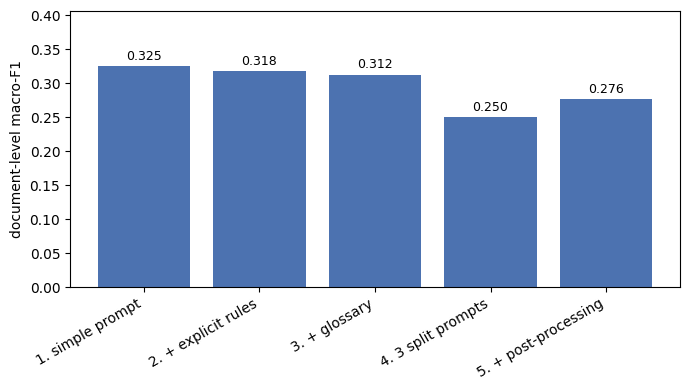

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary["stage"], summary["macro_f1"], color="#4c72b0")
ax.set_ylabel("document-level macro-F1")
ax.set_xticklabels(summary["stage"], rotation=30, ha="right")
ax.set_ylim(0, max(summary["macro_f1"]) * 1.25)
for i, v in enumerate(summary["macro_f1"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

A more detailed view:

In [14]:
for stage, (macro_f1, item_df) in results.items():
    tp, fp, fn, mm = item_df["TP"].sum(), item_df["FP"].sum(), item_df["FN"].sum(), item_df["MM"].sum()
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    print(f"{stage:25s} macro-F1={macro_f1:.3f}  TP={tp:4d} FP={fp:4d} FN={fn:4d} MM={mm:4d}  precision={precision:.2f} recall={recall:.2f}")

1. simple prompt          macro-F1=0.325  TP= 201 FP= 561 FN= 142 MM=  56  precision=0.26 recall=0.59
2. + explicit rules       macro-F1=0.318  TP= 203 FP= 579 FN= 153 MM=  43  precision=0.26 recall=0.57
3. + glossary             macro-F1=0.312  TP= 210 FP= 668 FN= 125 MM=  64  precision=0.24 recall=0.63
4. 3 split prompts        macro-F1=0.250  TP= 125 FP= 212 FN= 234 MM=  40  precision=0.37 recall=0.35
5. + post-processing      macro-F1=0.276  TP= 137 FP= 220 FN= 221 MM=  41  precision=0.38 recall=0.38


## 12. Per-item breakdown

Best Stage

In [15]:
best_stage = summary.loc[summary["macro_f1"].idxmax(), "stage"]
_, best_item_df = results[best_stage]
print(f"Best stage: {best_stage}")
print("\nTop 15 items by F1:")
print(best_item_df.sort_values("f1", ascending=False).head(15).to_string(index=False))
print("\nBottom 15 items by F1 (among items with at least 3 scored instances):")
scored = best_item_df.assign(N=best_item_df[["TP", "FP", "FN", "MM"]].sum(axis=1))
print(scored[scored["N"] >= 3].sort_values("f1").head(15).to_string(index=False))

Best stage: 1. simple prompt

Top 15 items by F1:
                        item       f1  TP  FP  FN  MM
                  creatinine 1.000000   1   0   0   1
             blood potassium 1.000000   1   0   0   1
                blood sodium 1.000000   1   0   0   1
                  hemoglobin 1.000000   1   0   0   2
                        spo2 0.972973  18   1   0   2
          history of allergy 0.848485  14   3   2   3
                       hc03- 0.800000   2   1   0   0
     cardiovascular diseases 0.782609   9   1   4   4
    antihypertensive therapy 0.764706  13   5   3   1
poly-pharmacological therapy 0.722222  13   5   5   0
              blood pressure 0.684211  13  10   2   7
                  heart rate 0.678571  19  17   1   4
            body temperature 0.678571  19  17   1   3
       chronic renal failure 0.666667   3   2   1   0
                          ph 0.666667   2   1   1   0

Bottom 15 items by F1 (among items with at least 3 scored instances):
               

All stages

In [16]:
for stage, (macro_f1, item_df) in results.items():
    bad = item_df[(item_df["TP"] == 0) & (item_df["FP"] >= 3)].sort_values("FP", ascending=False)
    total_fp = item_df["FP"].sum()
    print(f"\n=== {stage} (macro-F1 {macro_f1:.3f}) | total FP={total_fp} | {len(bad)} item con TP=0 e FP>=3 ===")
    print(bad[["item", "FP", "FN", "MM"]].head(15).to_string(index=False))


=== 1. simple prompt (macro-F1 0.325) | total FP=561 | 39 item con TP=0 e FP>=3 ===
                                                                                                   item  FP  FN  MM
situation description, like coughing, prolonged periods of straining, sudden abdominal pain, phlebotomy  17   0   0
                                                                   administration of oxygen/ventilation  13   3   0
                                                                                               covid 19  11   0   0
                                                                                              pregnancy  11   0   0
                                                                                  history of drug abuse  10   0   0
                                                                                   sars-cov-2 swab test  10   0   0
                                                                            administration of diuretics

1. simple prompt          macro-F1=0.417  TP= 271 FP= 366 FN=  86 MM=  42  precision=0.43 recall=0.76
2. + explicit rules       macro-F1=0.396  TP= 278 FP= 418 FN=  82 MM=  39  precision=0.40 recall=0.77
3. + glossary             macro-F1=0.407  TP= 286 FP= 441 FN=  73 MM=  40  precision=0.39 recall=0.80
4. 3 split prompts        macro-F1=0.277  TP= 139 FP= 145 FN= 228 MM=  32  precision=0.49 recall=0.38
5. + post-processing      macro-F1=0.301  TP= 151 FP= 153 FN= 215 MM=  33  precision=0.50 recall=0.41
